# Project GEO876 - Wildfire Mapping
Janis Büchel

### Setup and API

Required packages:

In [1]:
# Install Packages:

import pandas as pd
import numpy as np
from datetime import datetime
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import folium
import matplotlib.colors as mcolors
import branca.colormap as cm

To access the API, a map key is required, which can be requested on the website.

In [2]:
#Set map key:
MAP_KEY = "e5b967caf968ec1283cb213a30e9b9d4"

# Set base url:
url = "https://firms.modaps.eosdis.nasa.gov/api/"



### Data Availability


Show which sensors are available on the API:

In [3]:
# Create the correct API-url with the map key and show the list of sensors.
data_availability_url = f"{url}data_availability/csv/{MAP_KEY}/all"
df_data_avialiability = pd.read_csv(data_availability_url)

print("Following sensors are available:")
display(df_data_avialiability)



Following sensors are available:


,data_id,min_date,max_date
0,MODIS_NRT,2026-03-01,2026-05-20
1,MODIS_SP,2000-11-01,2026-02-28
2,VIIRS_NOAA20_NRT,2026-04-01,2026-05-20
3,VIIRS_NOAA20_SP,2018-04-01,2026-03-31
4,VIIRS_NOAA21_NRT,2024-01-17,2026-05-20
5,VIIRS_SNPP_NRT,2026-04-01,2026-05-20
6,VIIRS_SNPP_SP,2012-01-20,2026-03-31
7,LANDSAT_NRT,2022-06-20,2026-05-20
8,GOES_NRT,2022-08-09,2026-05-20
9,BA_MODIS,2000-11-01,2026-02-01


Filter for sensors which recorded wildfired today

In [4]:
# Convert max_date into a date
df_data_avialiability["max_date"] = pd.to_datetime(df_data_avialiability['max_date'])

# Date of today
date_today = pd.Timestamp.now().normalize()
date_string = pd.Timestamp.now().strftime("%d.%m.%Y %H:%M")
print(f"Date today: {date_string}\n")

# Filter for sensors with recordings today
df_available_sens = df_data_avialiability[df_data_avialiability["max_date"] == date_today]
print(f"Sensors with up to date data: \n {df_available_sens}")


Date today: 20.05.2026 21:58

Sensors with up to date data: 
             data_id    min_date   max_date
0         MODIS_NRT  2026-03-01 2026-05-20
2  VIIRS_NOAA20_NRT  2026-04-01 2026-05-20
4  VIIRS_NOAA21_NRT  2024-01-17 2026-05-20
5    VIIRS_SNPP_NRT  2026-04-01 2026-05-20
7       LANDSAT_NRT  2022-06-20 2026-05-20
8          GOES_NRT  2022-08-09 2026-05-20


### Data Collection

Collect data for one sensor (MODIS):

In [5]:
# Shows the data of the sensor for the desired area (world = [-180,-90,180,90]) and for the day range.
sensor = "MODIS_NRT"
focus_area = "world"
day_range = 2 # max. 5 days

area_url = f"{url}area/csv/{MAP_KEY}/{sensor}/{focus_area}/{day_range}"
df_area = pd.read_csv(area_url)

df_area

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight
0,-19.97248,122.93787,307.76,1.55,1.23,2026-05-19,9,Terra,MODIS,54,6.1NRT,293.37,10.77,D
1,-19.71391,123.47016,311.81,1.44,1.19,2026-05-19,9,Terra,MODIS,72,6.1NRT,292.61,13.55,D
2,-18.92347,122.14961,303.62,1.85,1.33,2026-05-19,9,Terra,MODIS,57,6.1NRT,291.45,8.02,D
3,-13.12103,132.98608,313.08,1.43,1.18,2026-05-19,9,Terra,MODIS,69,6.1NRT,293.84,12.20,D
4,-34.15297,-58.99096,301.03,1.79,1.31,2026-05-19,43,Terra,MODIS,37,6.1NRT,278.36,20.49,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9506,39.27535,-75.62231,321.21,1.90,1.30,2026-05-20,1931,Aqua,MODIS,95,6.1URT,303.77,15.95,D
9507,40.27313,-74.56506,323.05,1.50,1.20,2026-05-20,1932,Aqua,MODIS,95,6.1URT,301.28,18.89,D
9508,40.81936,-74.71651,314.56,1.50,1.20,2026-05-20,1932,Aqua,MODIS,95,6.1URT,298.66,11.21,D
9509,46.48238,-71.70123,307.40,1.00,1.00,2026-05-20,1933,Aqua,MODIS,95,6.1URT,296.31,5.49,D


Collect data for all three VIIRS sensors:

In [6]:
# Shows the data of the sensor for the desired area (world = [-180,-90,180,90]) and for the day range.
sensors = ["VIIRS_NOAA20_NRT", "VIIRS_NOAA21_NRT", "VIIRS_SNPP_NRT"]
focus_area = "world"
day_range = 2 # max. 5 days, needs to be at least 2 to get data for the past 24h

# df for with data from all three sensors:
df_viirs = []

for foc_sensor in sensors:
    area_url = f"{url}area/csv/{MAP_KEY}/{foc_sensor}/{focus_area}/{day_range}"
    df_sens = pd.read_csv(area_url)
    df_sens["sensor_id"] = foc_sensor
    df_viirs.append(df_sens)
    print(f"Data for {foc_sensor} loaded, total {len(df_sens)} rows.")

# Add all three dataframes into one big dataframe
df_viirs = pd.concat(df_viirs, ignore_index=True)
print(f"Total number of rows: {len(df_viirs)}\nFinal df:")
display(df_viirs.head())

Data for VIIRS_NOAA20_NRT loaded, total 47099 rows.
Data for VIIRS_NOAA21_NRT loaded, total 45815 rows.
Data for VIIRS_SNPP_NRT loaded, total 46489 rows.
Total number of rows: 139403
Final df:


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,sensor_id
0,-30.37219,27.41915,309.67,0.41,0.61,2026-05-19,1,N20,VIIRS,n,2.0NRT,279.67,1.16,N,VIIRS_NOAA20_NRT
1,-30.15406,29.94128,300.23,0.58,0.70,2026-05-19,1,N20,VIIRS,n,2.0NRT,282.02,1.08,N,VIIRS_NOAA20_NRT
2,-30.15405,29.94275,302.60,0.58,0.70,2026-05-19,1,N20,VIIRS,n,2.0NRT,282.17,1.53,N,VIIRS_NOAA20_NRT
3,-29.26657,30.51535,299.84,0.62,0.71,2026-05-19,1,N20,VIIRS,n,2.0NRT,277.77,0.71,N,VIIRS_NOAA20_NRT
4,-29.16551,30.44183,296.47,0.61,0.71,2026-05-19,1,N20,VIIRS,n,2.0NRT,281.05,2.23,N,VIIRS_NOAA20_NRT


### Data Cleaning ###

Filter for data with confidcence nominal or high:

In [7]:
df_viirs = df_viirs[(df_viirs["confidence"] == "n") | (df_viirs["confidence"] == "h")].copy()
print(f"{len(df_viirs)} rows with confidence nominal or high")

125955 rows with confidence nominal or high


Change acq_date und acq_time to datetime:

In [8]:
df_viirs["acq_time"] = df_viirs["acq_time"].astype(str) # Convert time to string
df_viirs["acq_time"] = df_viirs["acq_time"].str.zfill(4) # Fill with zeros

# Create new column with datetime
df_viirs["acq_datetime"] = pd.to_datetime(
    df_viirs["acq_date"] + " " + df_viirs["acq_time"], 
    format='%Y-%m-%d %H%M'
)
# Print new column
print(df_viirs[["acq_datetime"]].head())

         acq_datetime
0 2026-05-19 00:01:00
1 2026-05-19 00:01:00
2 2026-05-19 00:01:00
3 2026-05-19 00:01:00
4 2026-05-19 00:01:00


Filter for data from the last 24h

In [9]:
from datetime import datetime, timedelta

date_24h = datetime.now() - timedelta(hours=24 + 2) # plus 2h to get the utc time

# keep only data from the past 24h
df_viirs_24h = df_viirs[df_viirs["acq_datetime"] >= date_24h].copy()

print(f"date and time 24h ago (utc): {date_24h}")
print(f"number of rows from the past 24h: {len(df_viirs_24h)}")

date and time 24h ago (utc): 2026-05-19 19:58:57.551560
number of rows from the past 24h: 68568


Rename columns and display final df

In [10]:
# Select columns
df_viirs_fin = df_viirs_24h[["acq_datetime",
                         "sensor_id",
                         "latitude",
                         "longitude",
                         "bright_ti4",
                         "bright_ti5",
                         "frp",
                         "confidence",
                         "daynight"]].copy()


# Rename columns
df_viirs_fin = df_viirs_fin.rename(columns={
    "acq_datetime": "date/time",
    "latitude": "latitude",
    "longitude": "longitude",
    "bright_ti4": "fire_temperature_k",
    "bright_ti5": "ground_temperature_k",
    "frp": "intensity_mw",
    "sensor_id": "sensor",
    "confidence": "confidence"
})

# Add column withfire_temperature in °C
df_viirs_fin["fire_temperature_c"] = df_viirs_fin["fire_temperature_k"] - 273.15

# Show final dataframe
display(df_viirs_fin.head())

,date/time,sensor,latitude,longitude,fire_temperature_k,ground_temperature_k,intensity_mw,confidence,daynight,fire_temperature_c
21528,2026-05-19 20:00:00,VIIRS_NOAA20_NRT,36.98774,102.08210,303.55,278.56,1.99,n,N,30.40
21529,2026-05-19 20:00:00,VIIRS_NOAA20_NRT,36.98945,102.08234,304.42,277.56,1.76,n,N,31.27
21530,2026-05-19 20:00:00,VIIRS_NOAA20_NRT,39.81146,98.30028,313.80,283.12,1.83,n,N,40.65
21531,2026-05-19 20:00:00,VIIRS_NOAA20_NRT,39.81291,98.29436,299.94,281.43,1.83,n,N,26.79
21532,2026-05-19 20:00:00,VIIRS_NOAA20_NRT,39.84199,98.27412,296.85,275.56,1.02,n,N,23.70


Create two datasets, one for the day and one for the night\
A difference between the day recordings and the night recordings can be seen in the test plots.

In [11]:
df_viirs_night = df_viirs_fin[(df_viirs_fin["daynight"] == "N")].copy()
df_viirs_day = df_viirs_fin[(df_viirs_fin["daynight"] == "D")].copy()
print(f"Rows detected at night: {len(df_viirs_night)}\nRows detected at day: {len(df_viirs_day)}")

Rows detected at night: 17497
Rows detected at day: 51071


### GeoDataFrame and test visualizations ###

Convert the dataframe to a geodataframe

In [12]:
gdf_viirs = gpd.GeoDataFrame(
    df_viirs_fin, 
    geometry=gpd.points_from_xy(df_viirs_fin.longitude, df_viirs_fin.latitude),
    crs="EPSG:4326"  # WGS84
)

display(gdf_viirs.head())

,date/time,sensor,latitude,longitude,fire_temperature_k,ground_temperature_k,intensity_mw,confidence,daynight,fire_temperature_c,geometry
21528,2026-05-19 20:00:00,VIIRS_NOAA20_NRT,36.98774,102.08210,303.55,278.56,1.99,n,N,30.40,POINT (102.0821 36.98774)
21529,2026-05-19 20:00:00,VIIRS_NOAA20_NRT,36.98945,102.08234,304.42,277.56,1.76,n,N,31.27,POINT (102.08234 36.98945)
21530,2026-05-19 20:00:00,VIIRS_NOAA20_NRT,39.81146,98.30028,313.80,283.12,1.83,n,N,40.65,POINT (98.30028 39.81146)
21531,2026-05-19 20:00:00,VIIRS_NOAA20_NRT,39.81291,98.29436,299.94,281.43,1.83,n,N,26.79,POINT (98.29436 39.81291)
21532,2026-05-19 20:00:00,VIIRS_NOAA20_NRT,39.84199,98.27412,296.85,275.56,1.02,n,N,23.70,POINT (98.27412 39.84199)


Create a first test plot:

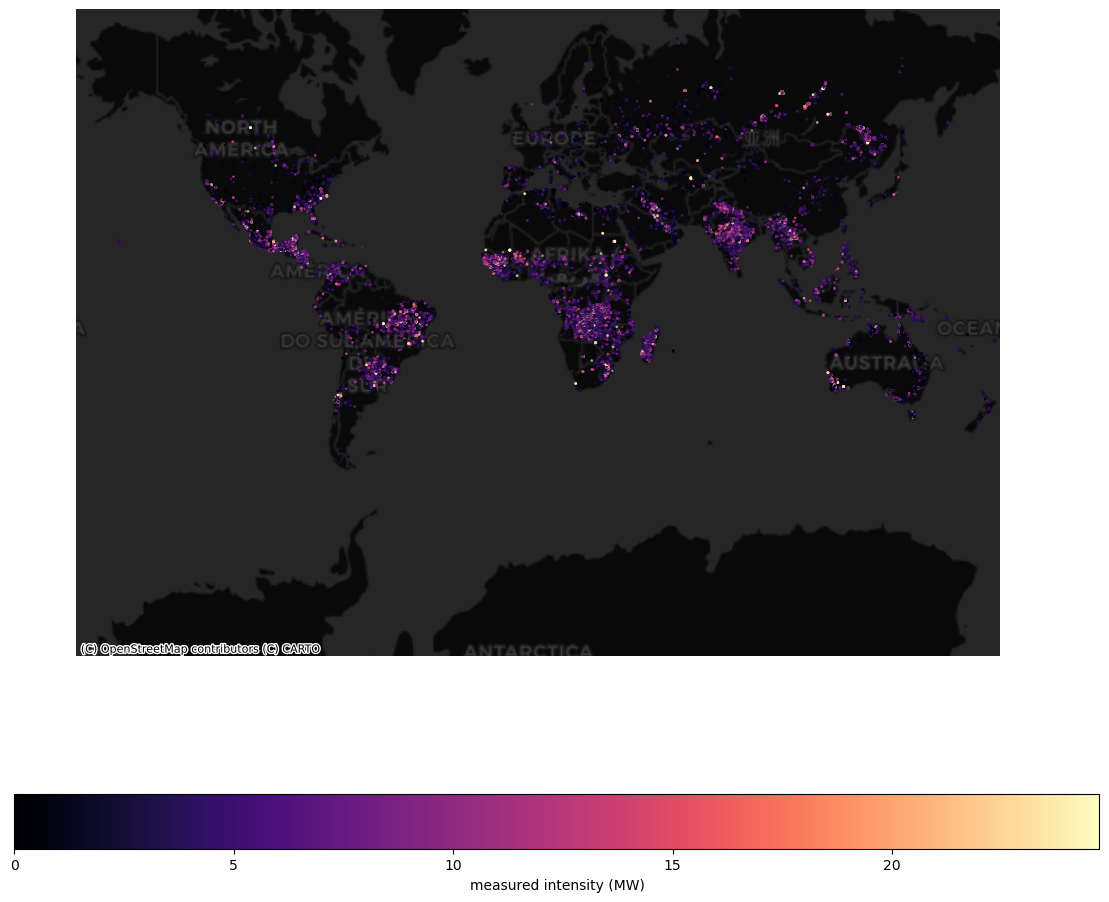

Recordings from the day differ from those during the night.


In [13]:
# Set CRS to Web Mercator to match contextily basemap
gdf_viirs = gdf_viirs.to_crs(epsg=3857)

# Create the initial plot
fig, ax = plt.subplots(figsize=(20, 12))

vmax = np.percentile(gdf_viirs["intensity_mw"], 95)

# Plot the data
gdf_viirs.plot(ax=ax,
               column="intensity_mw",
               legend=True,
               alpha=0.5,
               markersize=1,
               vmax=vmax,
               cmap="magma", # trying a different color scheme
               legend_kwds={
                   "label": "measured intensity (MW)",
                   "orientation": "horizontal",
                   "shrink":0.7
    })

# Add a basemap
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.DarkMatter)

# Hide axes
ax.set_axis_off()
plt.show()

print("Recordings from the day differ from those during the night.")

Create a test plot for day and night \
Try out different schemes and basemaps

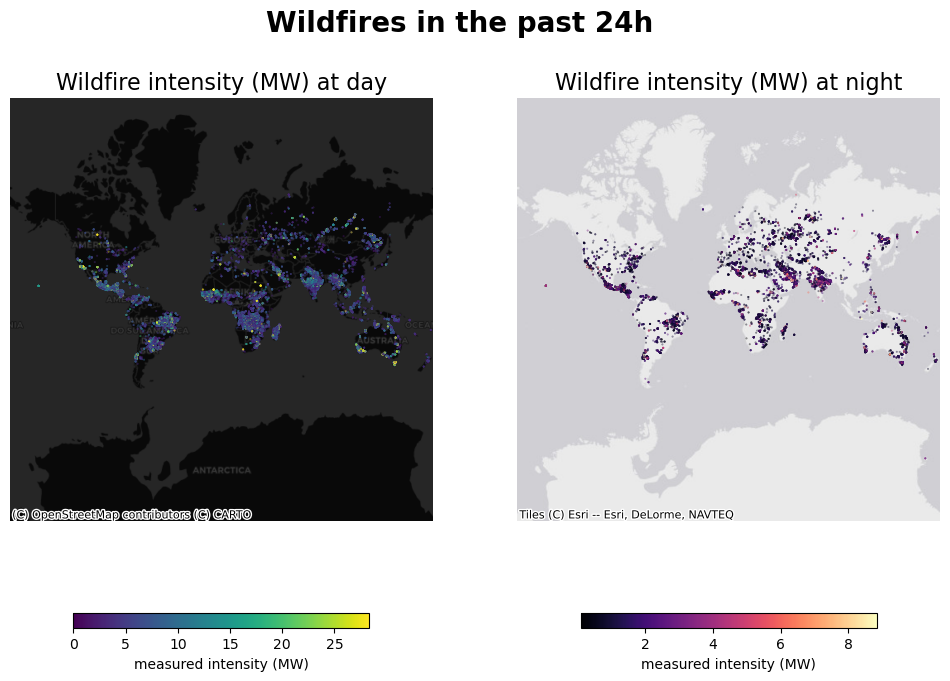

In [14]:
gdf_viirs_day = gpd.GeoDataFrame(
    df_viirs_day, 
    geometry=gpd.points_from_xy(df_viirs_day.longitude, df_viirs_day.latitude),
    crs="EPSG:4326"  # WGS84
).to_crs(epsg=3857)

gdf_viirs_night = gpd.GeoDataFrame(
    df_viirs_night, 
    geometry=gpd.points_from_xy(df_viirs_night.longitude, df_viirs_night.latitude),
    crs="EPSG:4326"
).to_crs(epsg=3857)

# Plot with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 8))

# Filter for outliers
vmax_day = np.percentile(gdf_viirs_day["intensity_mw"], 95)

gdf_viirs_day.plot(ax=axs[0],
               column="intensity_mw",
               legend=True,
               markersize=0.2,
               alpha=0.5,
               vmax=vmax_day,
               cmap="viridis", # trying different colors
               legend_kwds={
                   "label": "measured intensity (MW)",
                   "orientation": "horizontal",
                   "shrink":0.7
    })

vmax_night = np.percentile(gdf_viirs_night["intensity_mw"], 95)

gdf_viirs_night.plot(ax=axs[1],
               column="intensity_mw",
               legend=True,
               markersize=0.2,
               alpha=0.5,
               vmax=vmax_night,
               cmap="magma",
               legend_kwds={
                   "label": "measured intensity (MW)",
                   "orientation": "horizontal",
                   "shrink":0.7
    })

# Add a basemap
ctx.add_basemap(ax=axs[0], source=ctx.providers.CartoDB.DarkMatter) # trying different basemaps.
ctx.add_basemap(ax=axs[1], source=ctx.providers.Esri.WorldGrayCanvas)

# Set a title
fig.suptitle("Wildfires in the past 24h", fontsize=20, fontweight="bold")
axs[0].set_title("Wildfire intensity (MW) at day", fontsize=16, color="k")
axs[1].set_title("Wildfire intensity (MW) at night", fontsize=16, color="k")

for ax in axs:
    ax.set_xlim(-20000000, 20000000)
    ax.set_ylim(-20000000, 20000000)

# Hide axes
axs[0].set_axis_off()
axs[1].set_axis_off()
plt.show()

### Final folium map ###
Create an interactive plot

In [15]:
# Set CRS back to WGS84
gdf = gdf_viirs.to_crs(epsg=4326).copy()

gdf = gdf[gdf["intensity_mw"] < 30] # only keep values under 30, reduce outliers

# Filter for outliers
vmax = (gdf["intensity_mw"].max())
vmin = (gdf["intensity_mw"].min())

# Set Colormap
cmap = plt.get_cmap("viridis")
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# Set up legend
legend = cm.LinearColormap(
    colors=[mcolors.to_hex(cmap(i)) for i in np.linspace(0, 1, 6)],
    vmin=vmin,
    vmax=vmax,
    caption="Fire Intensity (MW)"
)

# Set center
center_lat = gdf.geometry.y.mean()
center_lon = gdf.geometry.x.mean()

# Create Folium map
map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=3,
    tiles="Esri.WorldGrayCanvas"
)

# Add data
for idx, row in gdf.iterrows():
    lon = row.geometry.y
    lat = row.geometry.x

    value = min(row["intensity_mw"], vmax)

    rgb = cmap(norm(value))
    color = mcolors.to_hex(rgb)

    folium.Circle(
        location=[row.geometry.y, row.geometry.x],
        radius=187.5, # size of the points in m; the footprint of a sensor is 375 x 375 m.
        stroke=False,
        fill=True,
        fill_opacity=0.6,
        color=color,
        fill_color=color,
        tooltip = (
            f"Date and time: {row['date/time']}<br>"
            f"Intensity: {row['intensity_mw']} MW<br>"
            f"Temperature: {row['fire_temperature_c']:.1f} °C")
    ).add_to(map)

# Add legend
legend.add_to(map)
style = "<style>.legend {background: white !important; padding: 10px; border-radius: 5px;} .legend svg text {fill: black !important;}</style>"
map.get_root().header.add_child(folium.Element(style))

# Add title
title = f'''
<div style="position:fixed; top:50px; left:100px; z-index:9999; color:black; font-family:sans-serif; ">
    <h1 style="margin: 0; font-size: 24px;">Potential Wildfires (Intensity in MW)</h1>
    <p style="margin: 5px 0 0 0; font-size: 14px; color: #333;">Date: {date_string}</p>
</div>
'''
map.get_root().html.add_child(folium.Element(title))

# Add description
description = '''<h6 style="position:fixed; bottom:25px; left:25px; z-index:9999; color:black; background:white; font-family:sans-serif; padding:10px;
">Recorded wildfires in the past 24h, colored<br>according to their intensity in MW.<br>
The data was recorded by the three VIIRS sensors<br>NOAA20 NRT, NOAA21 NRT, SNPP NRT.<br>
source: https://firms.modaps.eosdis.nasa.gov/api/<br> author: Janis Büchel </h6>'''
map.get_root().html.add_child(folium.Element(description))

# Show map
map
map.save("../output/wildfire_map.html") #saves file into output folder. If you don't have the same folder structure, delete "../output/".